# Error Analysis: the gender baseline

Where the control model is wrong, and how much is available in each pocket. This is the map for
deciding what to build next -- a feature is only worth adding if it can move rows in one of these
groups.

Predictions are out-of-fold: every row is predicted by a model that never saw it.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

from preprocessing import build_preprocessing_pipeline
from train import MODELS

df = pd.read_csv("data/train.csv")
X, y = df.drop(columns=["Survived"]), df["Survived"]

# built from the config rather than hand-rolled, so this notebook can't drift from what
# `train gender_baseline` actually runs
config = yaml.safe_load(open("configs/gender_baseline.yaml"))
baseline = Pipeline([
    ("preprocessing", build_preprocessing_pipeline(config.get("features", []))),
    ("model", MODELS[config["model"]](**config.get("params", {}))),
])
config

{'model': 'decision_stump',
 'features': [],
 'params': {'max_depth': 1, 'random_state': 42}}

In [2]:
# out-of-fold predictions, repeated. cross_val_predict can't take a repeated splitter (a row
# would land in several test folds), so the repeats are run by hand and the results stacked
REPEATS = 10
oof = pd.DataFrame(index=X.index, columns=range(REPEATS), dtype=int)

for repeat in range(REPEATS):
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=repeat)
    for train_idx, test_idx in folds.split(X, y):
        fitted = baseline.fit(X.iloc[train_idx], y.iloc[train_idx])
        oof.iloc[test_idx, repeat] = fitted.predict(X.iloc[test_idx])

# a depth-1 tree on this data splits on Sex in every fold, so the out-of-fold predictions should
# reproduce the plain rule exactly. worth asserting rather than assuming
gender_rule = (X["Sex"] == "female").astype(int)
print("OOF predictions identical to 'all women survive', every repeat:",
      all(oof[r].equals(gender_rule.astype(int)) for r in range(REPEATS)))
print(f"OOF accuracy: {(oof[0] == y).mean():.4f}")

OOF predictions identical to 'all women survive', every repeat: False
OOF accuracy: 0.7868


In [3]:
# one row per Sex x Pclass pocket
groups = pd.DataFrame({
    "Sex": X["Sex"],
    "Pclass": X["Pclass"],
    "predicted": oof[0],
    "actual": y,
})
groups["correct"] = groups["predicted"] == groups["actual"]
groups["group"] = groups["Sex"] + " " + groups["Pclass"].map({1: "1st", 2: "2nd", 3: "3rd"})

summary = groups.groupby("group").agg(
    n=("correct", "size"),
    correct=("correct", "sum"),
    predicted=("predicted", "first"),
).assign(wrong=lambda d: d["n"] - d["correct"])
summary["accuracy"] = summary["correct"] / summary["n"]
summary["share_of_all_errors"] = summary["wrong"] / summary["wrong"].sum()
summary = summary.sort_values("wrong", ascending=False)
summary[["n", "predicted", "correct", "wrong", "accuracy", "share_of_all_errors"]].round(3)

,n,predicted,correct,wrong,accuracy,share_of_all_errors
group,,,,,,
female 3rd,144,1.0,72,72,0.500,0.379
male 3rd,347,0.0,300,47,0.865,0.247
male 1st,122,0.0,77,45,0.631,0.237
male 2nd,108,0.0,91,17,0.843,0.089
female 2nd,76,1.0,70,6,0.921,0.032
female 1st,94,1.0,91,3,0.968,0.016


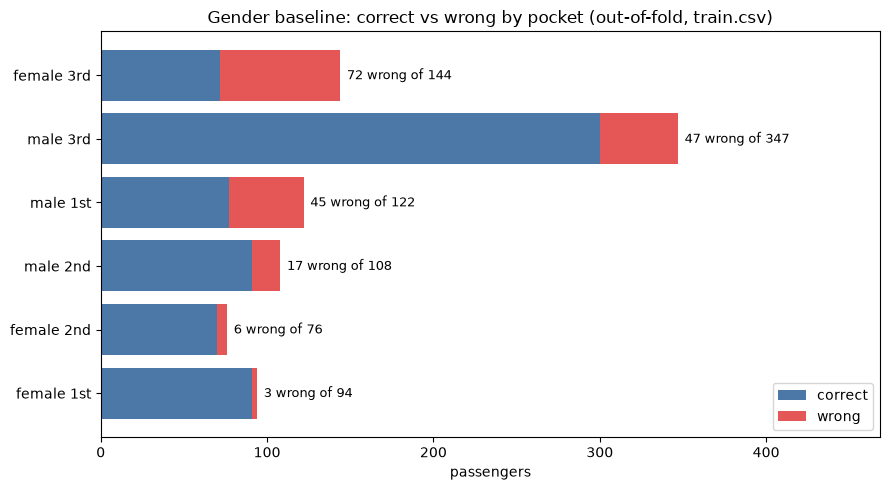

In [4]:
# the chart: how many rows in each pocket the rule gets right and wrong
plot_order = summary.index.tolist()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_order, summary["correct"], color="#4c78a8", label="correct")
ax.barh(plot_order, summary["wrong"], left=summary["correct"], color="#e45756", label="wrong")
for i, row in enumerate(summary.itertuples()):
    ax.text(row.n + 4, i, f"{row.wrong} wrong of {row.n}", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, summary["n"].max() * 1.35)
ax.set_xlabel("passengers")
ax.set_title("Gender baseline: correct vs wrong by pocket (out-of-fold, train.csv)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [5]:
# what each pocket is actually worth. beating the rule inside a pocket means separating its
# minority from its majority -- the ceiling is the error count, and a coin flip gains nothing
gain = summary.copy()
gain["minority_rate"] = gain["wrong"] / gain["n"]
# net rows if you could call this pocket at a given hit rate, betting on every row in it
for hit in (0.60, 0.70, 0.80):
    gain[f"net@{hit:.0%}"] = ((2 * hit - 1) * gain["n"]).round(0)
gain["ceiling"] = gain["wrong"]
print("+14 net rows on the 418-row test set is 0.80 on the leaderboard;")
print("scaled to these 891 rows that is about +30.\n")
gain[["n", "wrong", "minority_rate", "ceiling", "net@60%", "net@70%", "net@80%"]].round(3)

+14 net rows on the 418-row test set is 0.80 on the leaderboard;
scaled to these 891 rows that is about +30.



,n,wrong,minority_rate,ceiling,net@60%,net@70%,net@80%
group,,,,,,,
female 3rd,144,72,0.500,72,29.0,58.0,86.0
male 3rd,347,47,0.135,47,69.0,139.0,208.0
male 1st,122,45,0.369,45,24.0,49.0,73.0
male 2nd,108,17,0.157,17,22.0,43.0,65.0
female 2nd,76,6,0.079,6,15.0,30.0,46.0
female 1st,94,3,0.032,3,19.0,38.0,56.0


## How to read this

- **`wrong`** is the ceiling for a pocket: fix every error there and that's what you gain. Two
  pockets hold most of it, and they need opposite corrections -- 3rd-class women who died, and
  1st-class men who survived.
- **`minority_rate`** is how hard the pocket is. Near 0.5 means the rule is guessing; near 0.1
  means the rule is nearly right and any feature you add will mostly break correct predictions.
- **`net@X%`** is what betting on the whole pocket returns at a given hit rate: `(2 x hit - 1) x n`.
  Below 50% you lose rows. This is the number to beat, and the standard error on it is about `sqrt(n)`,
  so small pockets can't be measured no matter how good the idea is.
- A feature that helps a pocket where the rule is already 95% right has to be *very* precise to
  break even. Prefer the pockets nearest a coin flip.